## 환경 세팅
파이토치(PyTorch)와 시각화를 위한 맷플롯립(Matplotlib), 넘파이(NumPy)를 불러옵니다.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 시각화 스타일 설정
plt.style.use('ggplot')

## Ch 1. 데이터 생성 및 확인
모델이 학습할 가상의 데이터(주황색 점들)를 만듭니다. 
현실의 노이즈가 섞인 $y = 2x + 1$ 형태의 데이터를 생성하고 시각화합니다.

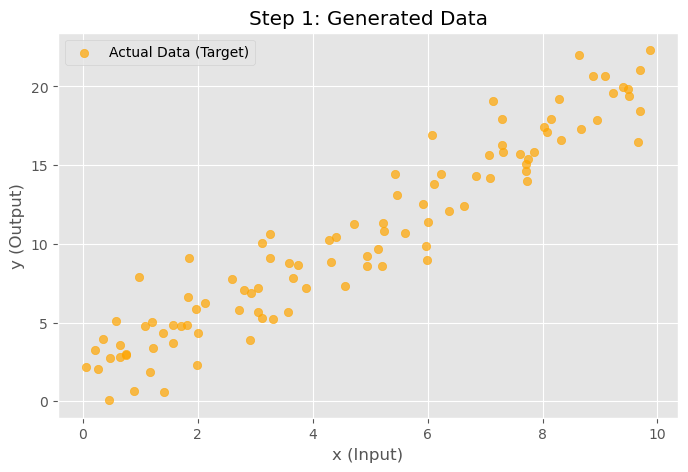

In [2]:
# --- [마법의 주문 추가] 라이브러리 간 충돌을 무시하도록 강제 설정 ---
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
# 주피터 환경에서 그래프가 안전하게 셀 안에 그려지도록 보장
%matplotlib inline 
# -------------------------------------------------------------

import numpy as np
import torch
import matplotlib.pyplot as plt

np.random.seed(42)

x_raw = np.random.rand(100, 1) * 10
y_raw = 2 * x_raw + 1 + np.random.randn(100, 1) * 2 

X = torch.tensor(x_raw, dtype=torch.float32)
Y = torch.tensor(y_raw, dtype=torch.float32)

plt.figure(figsize=(8, 5))
plt.scatter(x_raw, y_raw, color='orange', alpha=0.7, label='Actual Data (Target)')
plt.title("Step 1: Generated Data")
plt.xlabel("x (Input)")
plt.ylabel("y (Output)")
plt.legend()
plt.show()

## Ch 1 & Ch 5. 신경망 모델 및 손실 함수 정의
은닉층을 포함한 작은 신경망을 만듭니다. 
파라미터($w, b$)를 생성할 때 `requires_grad=True`를 설정하여 **미분(Gradient) 추적을 활성화**하는 것이 핵심입니다.

In [3]:
torch.manual_seed(42)

# 1. 파라미터(다이얼) 초기화 (Ch 3 Step 1: 산에 무작위로 낙하)
# 입력(1) -> 은닉층(5) -> 출력층(1) 구조
w1 = torch.randn(1, 5, requires_grad=True) 
b1 = torch.zeros(1, requires_grad=True)    
w2 = torch.randn(5, 1, requires_grad=True) 
b2 = torch.zeros(1, requires_grad=True)    

# 2. 순전파 함수 (입력에서 출력으로의 계산 흐름)
def forward_pass(x):
    # 은닉층 계산 + ReLU 활성화 함수 (비선형성 부여)
    h = torch.relu(torch.matmul(x, w1) + b1) 
    # 출력층 계산 (예측값)
    y_pred = torch.matmul(h, w2) + b2
    return y_pred

# 3. 손실 함수 (MSE: 평균 제곱 오차)
def mse_loss(y_pred, y_true):
    return ((y_pred - y_true)**2).mean()

## Ch 3 & Ch 4. 학습 루프 (SGD + 역전파)
확률적 경사 하강법(SGD)을 이용해 미니배치 단위로 데이터를 학습합니다.
`loss.backward()`가 호출되는 순간, 우리가 배운 **연쇄법칙(Chain Rule)을 통한 역전파**가 마법처럼 자동으로 계산됩니다.

In [4]:
# 하이퍼파라미터 설정
learning_rate = 0.005 # 보폭 (너무 크면 발산, 너무 작으면 느림)
epochs = 1000         # 전체 데이터를 몇 번 반복해서 볼 것인가
batch_size = 10       # 미니배치 크기 (SGD 특성)

losses = []
num_batches = X.shape[0] // batch_size

print("🚀 학습 시작 (경사 하강법 + 역전파 진행 중...)")

for epoch in range(epochs):
    # 매 에폭마다 데이터를 무작위로 섞음 (SGD의 노이즈 효과 극대화)
    indices = torch.randperm(X.shape[0])
    X_shuffled = X[indices]
    Y_shuffled = Y[indices]
    
    epoch_loss = 0.0
    
    # 미니배치(10개) 단위로 반복
    for i in range(0, X.shape[0], batch_size):
        xi = X_shuffled[i:i+batch_size]
        yi = Y_shuffled[i:i+batch_size]
        
        # [Step 1] 예측값 계산 (순전파)
        y_pred = forward_pass(xi)
        
        # [Step 2] 채점 (손실 함수 계산)
        loss = mse_loss(y_pred, yi)
        epoch_loss += loss.item()
        
        # [Step 3] 나침반 확인 (역전파를 통한 미분값 계산)
        loss.backward()
        
        # [Step 4] 다이얼 조절 (경사 하강법 업데이트: 기울기 반대 방향으로 이동)
        with torch.no_grad(): # 업데이트 중에는 미분 추적 잠시 중단
            w1 -= learning_rate * w1.grad
            b1 -= learning_rate * b1.grad
            w2 -= learning_rate * w2.grad
            b2 -= learning_rate * b2.grad
            
            # (중요 제약사항) 업데이트 완료 후 기존 미분값 초기화
            w1.grad.zero_()
            b1.grad.zero_()
            w2.grad.zero_()
            b2.grad.zero_()
            
    # 에폭당 평균 손실 기록
    avg_epoch_loss = epoch_loss / num_batches
    losses.append(avg_epoch_loss)
    
    # 200 에폭마다 진행 상황 출력
    if (epoch+1) % 200 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] 완료 - 평균 Loss: {avg_epoch_loss:.4f}")

print("✅ 학습 완료!")

🚀 학습 시작 (경사 하강법 + 역전파 진행 중...)
Epoch [200/1000] 완료 - 평균 Loss: 3.2075
Epoch [400/1000] 완료 - 평균 Loss: 3.5424
Epoch [600/1000] 완료 - 평균 Loss: 3.5781
Epoch [800/1000] 완료 - 평균 Loss: 3.3339
Epoch [1000/1000] 완료 - 평균 Loss: 3.8892
✅ 학습 완료!


## 결과 시각화: 추상과 현실
왼쪽 그래프는 추상적인 파라미터 세계에서 '어두운 골짜기(최솟값)'로 내려가는 과정(Loss 감소)을 보여주며, 
오른쪽 그래프는 그 결과 현실 세계에서 초록색 선이 데이터(주황색 점)에 완벽하게 적합(Fitting)된 모습을 보여줍니다.

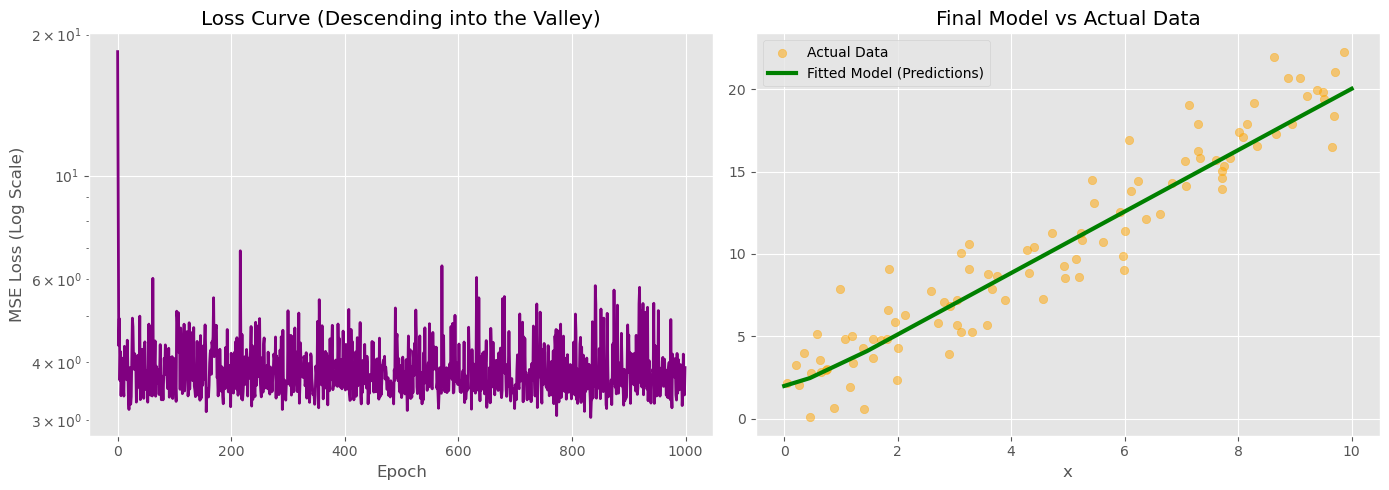

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Loss 곡선 (추상 세계의 하강 기록)
ax1.plot(losses, color='purple', linewidth=2)
ax1.set_title("Loss Curve (Descending into the Valley)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss (Log Scale)")
ax1.set_yscale('log') # 급격히 떨어지는 초반과 미세조정되는 후반을 잘 보기 위해 로그 스케일 사용

# 2. 최종 모델 적합 상태 (현실 세계의 결과)
ax2.scatter(x_raw, y_raw, color='orange', alpha=0.5, label='Actual Data')

# 학습된 파라미터로 부드러운 예측선 그리기
x_test = torch.linspace(0, 10, 200).unsqueeze(1)
with torch.no_grad():
    y_test_pred = forward_pass(x_test).numpy()

ax2.plot(x_test.numpy(), y_test_pred, color='green', linewidth=3, label='Fitted Model (Predictions)')
ax2.set_title("Final Model vs Actual Data")
ax2.set_xlabel("x")
ax2.legend()

plt.tight_layout()
plt.show()